<a href="https://www.kaggle.com/code/mani01shankar/mani-shankar-s-notebook?scriptVersionId=301571430" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/global-weather-repository/GlobalWeatherRepository.csv
/kaggle/input/global-weather-repository/state.db


# Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

file = "/kaggle/input/global-weather-repository/GlobalWeatherRepository.csv"
df = pd.read_csv(file)

print("Shape:", df.shape)
df.head()


Shape: (127841, 41)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [3]:
df[df.duplicated()].head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination


# Data info

In [4]:

print(df.columns)
df.info()

print("\nMissing values:")
print(df.isnull().sum())

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127841 entries, 0 to 127840
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------ 

In [5]:
df['last_updated'] = pd.to_datetime(df['last_updated'])

print(df['last_updated'].dtype)

datetime64[ns]


In [6]:
df['year'] = df['last_updated'].dt.year
df['month'] = df['last_updated'].dt.month
df['dayofweek'] = df['last_updated'].dt.dayofweek

df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,year,month,dayofweek
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15:00,26.6,79.8,Partly Cloudy,...,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55,2024,5,3
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45:00,19.0,66.2,Partly cloudy,...,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55,2024,5,3
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45:00,23.0,73.4,Sunny,...,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55,2024,5,3
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45:00,6.3,43.3,Light drizzle,...,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55,2024,5,3
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45:00,26.0,78.8,Partly cloudy,...,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55,2024,5,3


# Monthly Aggregation

month
1     16.072073
2     16.713934
3     19.586486
4     21.965060
5     23.960472
6     25.704565
7     26.019444
8     25.747953
9     24.248834
10    21.602371
11    18.894618
12    17.002060
Name: temperature_celsius, dtype: float64


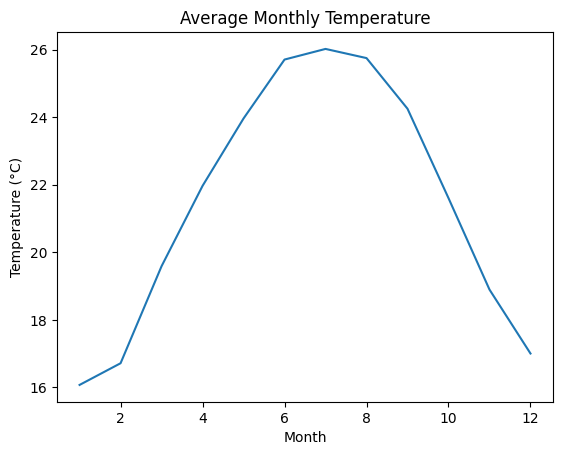

In [7]:
monthly_temp = df.groupby('month')['temperature_celsius'].mean()

print(monthly_temp)

plt.plot(monthly_temp.index, monthly_temp.values)
plt.title("Average Monthly Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

In [8]:
extreme_heat = df[
    df['temperature_celsius'] >
    df['temperature_celsius'].quantile(0.95)
]

print("Number of extreme heat records:", extreme_heat.shape[0])

extreme_heat[['country','location_name','temperature_celsius']].head()

Number of extreme heat records: 6242


,country,location_name,temperature_celsius
12,Bahrain,Manama,36.0
13,Bangladesh,Dhaka,38.4
30,Cambodia,Phnom Penh,38.0
34,Chad,N'djamena,37.2
77,India,New Delhi,42.0


In [9]:
# Average temperature by country

country_temp = df.groupby('country')['temperature_celsius'].mean().reset_index()

print(country_temp.head())

       country  temperature_celsius
0  Afghanistan            19.184170
1      Albania            19.904262
2      Algeria            21.006860
3      Andorra             9.445205
4       Angola            26.114460


In [10]:
fig = px.choropleth(
    country_temp,
    locations="country",
    locationmode="country names",
    color="temperature_celsius",
    title="Global Average Temperature by Country"
)

fig.show()

In [11]:
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Summer"
    elif month in [6,7,8]:
        return "Monsoon"
    else:
        return "Autumn"

df['season'] = df['month'].apply(get_season)

df[['month','season']].head()

,month,season
0,5,Summer
1,5,Summer
2,5,Summer
3,5,Summer
4,5,Summer


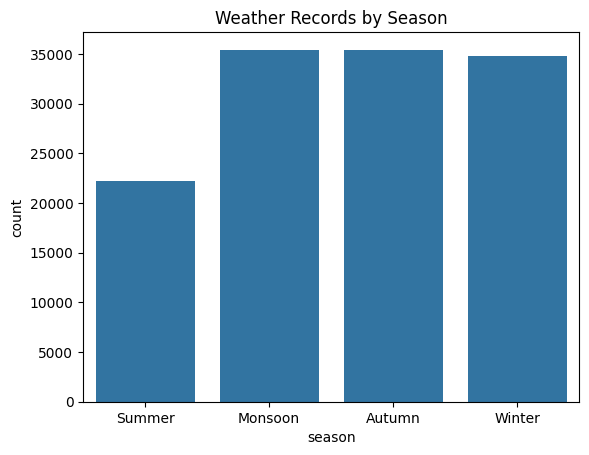

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='season')
plt.title("Weather Records by Season")
plt.show()

In [13]:
season_temp = df.groupby(['country','season'])['temperature_celsius'].mean().reset_index()

season_temp.head()

,country,season,temperature_celsius
0,Afghanistan,Autumn,21.148901
1,Afghanistan,Monsoon,30.364835
2,Afghanistan,Summer,20.381579
3,Afghanistan,Winter,5.055866
4,Albania,Autumn,19.011538


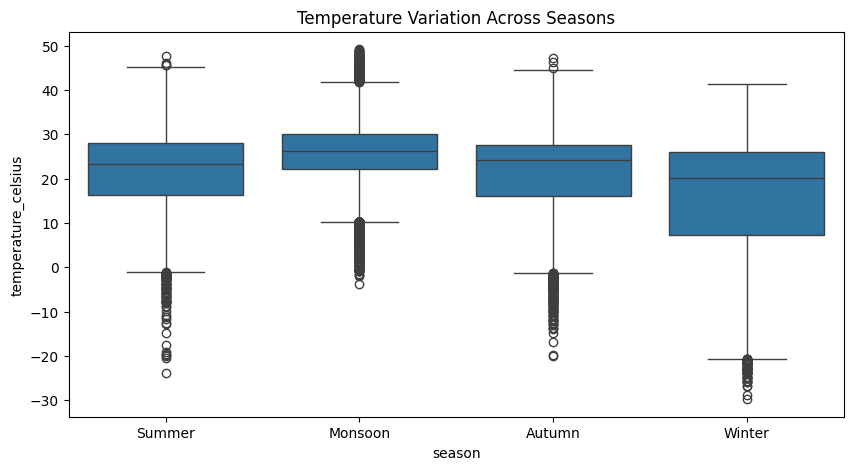

In [14]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='season',
    y='temperature_celsius'
)

plt.title("Temperature Variation Across Seasons")
plt.show()


**1. Is there a statistically significant linear correlation between high temperatures andhumidity levels across different climate zones?**


Correlation:                      temperature_celsius  humidity
temperature_celsius             1.000000 -0.344232
humidity                       -0.344232  1.000000


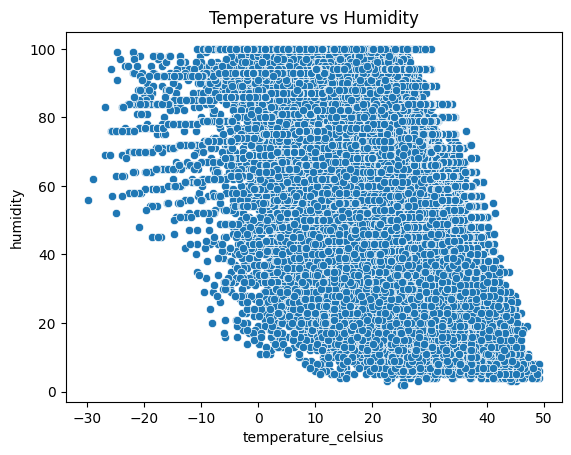

In [15]:
print("Correlation:", df[['temperature_celsius','humidity']].corr())

sns.scatterplot(data=df,x='temperature_celsius',y='humidity')
plt.title("Temperature vs Humidity")
plt.show()

**2. How strongly does wind speed correlate with changes in atmospheric pressure?**

Correlation Matrix:
             wind_kph  pressure_mb
wind_kph     1.000000    -0.084545
pressure_mb -0.084545     1.000000


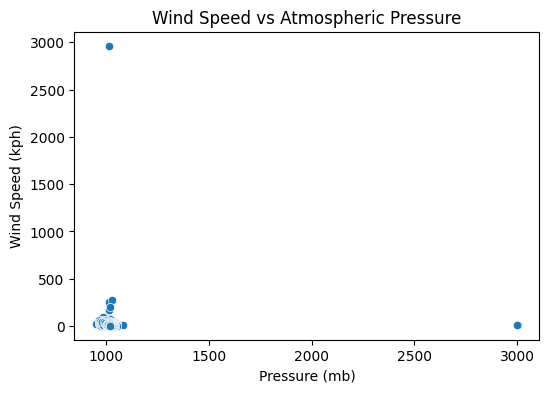

In [16]:
# Wind speed vs atmospheric pressure correlation

corr = df[['wind_kph','pressure_mb']].corr()

print("Correlation Matrix:")
print(corr)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.scatterplot(data=df,
                x='pressure_mb',
                y='wind_kph')

plt.title("Wind Speed vs Atmospheric Pressure")
plt.xlabel("Pressure (mb)")
plt.ylabel("Wind Speed (kph)")

plt.show()


**3. Which variables (e.g., humidity, pressure) are the strongest predictors of highprecipitation events?**


In [17]:
# Correlation of precipitation with other numeric variables

precip_corr = df.corr(numeric_only=True)['precip_mm'].sort_values(ascending=False)

print("Correlation with precipitation:")
print(precip_corr)

Correlation with precipitation:
precip_mm                       1.000000
precip_in                       0.997978
cloud                           0.216160
humidity                        0.173524
longitude                       0.062766
feels_like_celsius              0.058362
feels_like_fahrenheit           0.058358
gust_mph                        0.043675
gust_kph                        0.043657
temperature_fahrenheit          0.030950
temperature_celsius             0.030935
wind_degree                     0.013652
air_quality_Carbon_Monoxide     0.009104
wind_mph                        0.007150
wind_kph                        0.007138
month                           0.005861
moon_illumination               0.003959
dayofweek                      -0.000440
year                           -0.018563
last_updated_epoch             -0.018896
air_quality_Sulphur_dioxide    -0.023068
air_quality_Nitrogen_dioxide   -0.030243
visibility_km                  -0.038733
air_quality_PM10         

**4. How have average monthly temperatures shifted globally over the recorded period?**

month
1     16.072073
2     16.713934
3     19.586486
4     21.965060
5     23.960472
6     25.704565
7     26.019444
8     25.747953
9     24.248834
10    21.602371
11    18.894618
12    17.002060
Name: temperature_celsius, dtype: float64


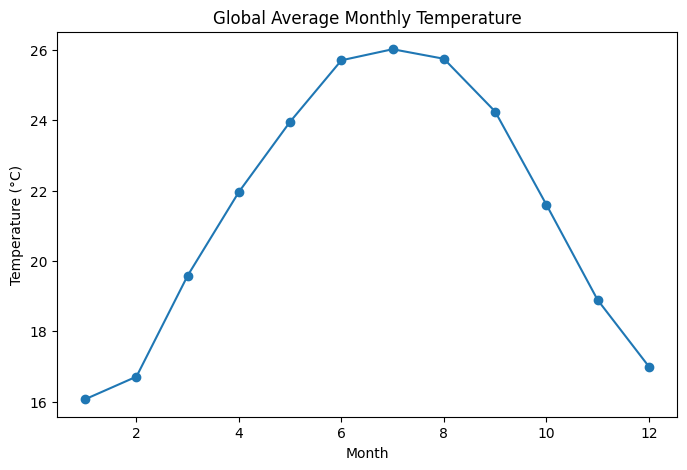

In [18]:
# Average monthly temperature globally

monthly_temp = df.groupby('month')['temperature_celsius'].mean()

print(monthly_temp)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(monthly_temp.index, monthly_temp.values, marker='o')

plt.title("Global Average Monthly Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")

plt.show()


**5. Are there recurring seasonal patterns in precipitation that vary significantly betweenthe Northern and Southern Hemispheres?**


Northern Hemisphere Monthly Rainfall
month
1     0.080341
2     0.068830
3     0.080325
4     0.092715
5     0.146734
6     0.155454
7     0.198269
8     0.176778
9     0.175408
10    0.132862
11    0.115450
12    0.082912
Name: precip_mm, dtype: float64

Southern Hemisphere Monthly Rainfall
month
1     0.273495
2     0.239011
3     0.292005
4     0.259589
5     0.170210
6     0.084674
7     0.057599
8     0.071322
9     0.072665
10    0.112839
11    0.210999
12    0.212611
Name: precip_mm, dtype: float64


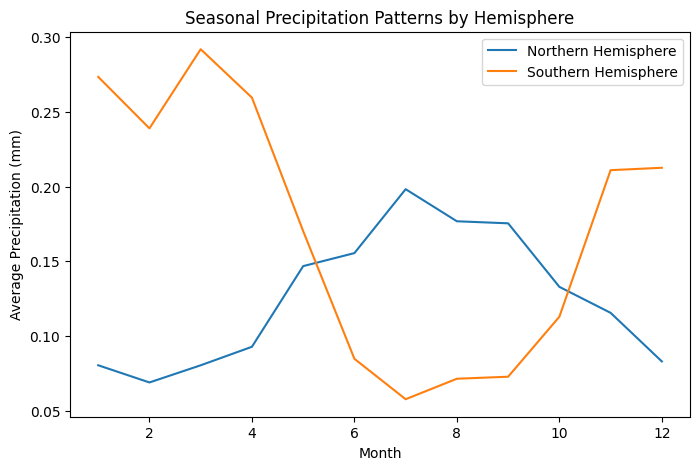

In [19]:
# Separate Northern and Southern Hemisphere

north = df[df['latitude'] > 0]
south = df[df['latitude'] < 0]

# Monthly precipitation averages
north_rain = north.groupby('month')['precip_mm'].mean()
south_rain = south.groupby('month')['precip_mm'].mean()

print("Northern Hemisphere Monthly Rainfall")
print(north_rain)

print("\nSouthern Hemisphere Monthly Rainfall")
print(south_rain)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(north_rain.index, north_rain.values, label="Northern Hemisphere")
plt.plot(south_rain.index, south_rain.values, label="Southern Hemisphere")

plt.xlabel("Month")
plt.ylabel("Average Precipitation (mm)")
plt.title("Seasonal Precipitation Patterns by Hemisphere")

plt.legend()

plt.show()

**6. Which regions experience the highest daily temperature swings (diurnal range)?**

In [20]:
# Calculate diurnal temperature range (approx)

df['diurnal_range'] = abs(df['temperature_celsius'] - df['feels_like_celsius'])

# Regions with highest temperature swings
top_regions = df.sort_values('diurnal_range', ascending=False)[
    ['country','location_name','temperature_celsius','feels_like_celsius','diurnal_range']
].head(10)

print("Regions with Highest Temperature Swings:")
print(top_regions)

Regions with Highest Temperature Swings:
                  country        location_name  temperature_celsius  \
3394              Jamaica       Norman Gardens                 32.0   
75707            Malaysia         Kuala Lumpur                 32.3   
20250            Thailand                  Nan                 32.2   
80768            Thailand                  Nan                 32.0   
1586             Cambodia           Phnom Penh                 32.0   
10577            Thailand                  Nan                 32.3   
102722  Brunei Darussalam  Bandar Seri Begawan                 32.2   
7477             Thailand                  Nan                 32.4   
421              Cameroon              Yaounde                 32.0   
21425            Malaysia         Kuala Lumpur                 33.0   

        feels_like_celsius  diurnal_range  
3394                  49.9           17.9  
75707                 49.9           17.6  
20250                 49.6           17.4  
8


**7. How do average wind speeds in coastal regions compare to inland or mountainousclimate zones?**


In [21]:
# Average wind speed by location

wind_location = df.groupby(['country','location_name'])['wind_kph'].mean().reset_index()

# Top windy regions
top_wind = wind_location.sort_values('wind_kph', ascending=False).head(10)

print("Locations with Highest Average Wind Speed:")
print(top_wind)

Locations with Highest Average Wind Speed:
                             country   location_name   wind_kph
121                           Kuwait          Kuwait  37.800000
116                            Kenya         Mombasa  32.800000
130                            Libya         Tripoli  31.700000
94                           Iceland       Grindavik  30.375000
188                          Polônia         Moldova  29.500000
214                          Somalia       Mogadishu  27.738872
140                         Maldives        Felidhoo  27.267647
200  Saint-Vincent-et-les-Grenadines       Kingstown  27.000000
245     USA United States of America           Palau  27.000000
96                           Iceland  Vestmannaeyjar  26.178066



**8. Which specific countries or continents are currently showing the highest rate oftemperature increase?**


In [22]:
# Average temperature by country and year

temp_trend = df.groupby(['country','year'])['temperature_celsius'].mean().reset_index()

# Calculate temperature increase per country
temp_growth = temp_trend.groupby('country')['temperature_celsius'].agg(['min','max'])

temp_growth['increase'] = temp_growth['max'] - temp_growth['min']

# Top countries with highest temperature increase
top_increase = temp_growth.sort_values('increase', ascending=False).head(10)

print("Countries with Highest Temperature Increase:")
print(top_increase)

Countries with Highest Temperature Increase:
                  min        max   increase
country                                    
Russia     -11.768966  15.618182  27.387147
Ukraine     -8.069841  18.504367  26.574208
Belarus    -10.368254  15.893013  26.261267
Kazakhstan -13.247619  12.075877  25.323496
Latvia      -8.811111  15.704405  24.515516
Lithuania   -8.947619  15.525877  24.473496
Finland     -9.780952  14.239738  24.020690
Iraq        12.385714  35.335808  22.950094
Romania     -0.966667  21.954386  22.921053
Armenia      0.142857  22.620524  22.477667



**9. Which geographic regions are identified as "high-precipitation zones" during specificmonths?**


In [23]:
# Monthly precipitation by region

rain_region = df.groupby(['month','country'])['precip_mm'].mean().reset_index()

# Highest precipitation regions
high_rain_regions = rain_region.sort_values('precip_mm', ascending=False).head(10)

print("High Precipitation Regions by Month:")
print(high_rain_regions)

High Precipitation Regions by Month:
      month                           country  precip_mm
1018      6  Lao People's Democratic Republic   1.970000
1215      7                           Letonia   1.830000
1276      7                      Sierra Leone   1.675593
1227      7                           Malásia   1.550000
1187      7                            Guinea   1.486000
1390      8                            Guinea   1.380000
1188      7                     Guinea-Bissau   1.350833
499       3                  Papua New Guinea   1.269722
1655      9                      Sierra Leone   1.250000
1469      8                      Sierra Leone   1.228548



**10. What are the top 1% of extreme wind speed events recorded, and where did theyoccur?**


In [24]:
# Top 1% extreme wind speed events

threshold = df['wind_kph'].quantile(0.99)

print("Extreme Wind Speed Threshold:", threshold)

extreme_wind = df[df['wind_kph'] >= threshold]

top_events = extreme_wind[['country','location_name','wind_kph']].sort_values(
    'wind_kph', ascending=False
).head(10)

print("Top Extreme Wind Speed Events:")
print(top_events)

Extreme Wind Speed Threshold: 37.4
Top Extreme Wind Speed Events:
                     country   location_name  wind_kph
7601                 Burundi       Bujumbura    2963.2
7248                Ethiopia     Addis Ababa     272.2
1193                 Burundi       Bujumbura     258.8
8675   Saint Kitts and Nevis      Basseterre     205.9
834             Fiji Islands            Suva     172.1
51526                Iceland  Vestmannaeyjar      91.1
9129                Barbados      Bridgetown      81.0
19892                 Norway            Oslo      78.1
35380                Iceland  Vestmannaeyjar      76.7
43180                Iceland  Vestmannaeyjar      76.0



**11. Can we identify specific dates where temperatures deviated by more than twostandard deviations from the historical mean for a region?**


In [25]:
# Mean and standard deviation of temperature

mean_temp = df['temperature_celsius'].mean()
std_temp = df['temperature_celsius'].std()

print("Mean Temperature:", mean_temp)
print("Standard Deviation:", std_temp)

# Identify extreme temperature deviations

extreme_temp = df[
    (df['temperature_celsius'] > mean_temp + 2*std_temp) |
    (df['temperature_celsius'] < mean_temp - 2*std_temp)
]

# Show important columns
result = extreme_temp[['country','location_name','last_updated','temperature_celsius']].head(10)

print("Temperature Deviations (>2σ):")
print(result)

Mean Temperature: 21.4781478555393
Standard Deviation: 9.662606187637271
Temperature Deviations (>2σ):
          country location_name        last_updated  temperature_celsius
35          Chile      Santiago 2024-05-16 04:45:00                  1.0
77          India     New Delhi 2024-05-16 14:15:00                 42.0
229          Chad     N'djamena 2024-05-16 15:00:00                 42.0
230         Chile      Santiago 2024-05-16 10:00:00                  2.0
346  Saudi Arabia        Riyadh 2024-05-16 17:15:00                 41.0
424          Chad     N'djamena 2024-05-17 17:00:00                 42.0
616          Chad     N'djamena 2024-05-18 15:30:00                 43.0
659         India     New Delhi 2024-05-18 20:00:00                 41.0
707         Niger        Niamey 2024-05-18 15:30:00                 43.0
747         Sudan      Khartoum 2024-05-18 16:30:00                 42.5


**Are there regions experiencing "flash" precipitation events that fall outside of expected seasonal trends?**